In [6]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, SEC_PALETTE, style_ax, legend, country_handles

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Definition af grøn energi

Vi måler andelen af **bruttoindenlandsk forbrug (GIC)** som kommer fra grønne kilder.
GIC er standardmålet for energimix og inkluderer importeret energi (modsat primærproduktion).

| Kilde | Eurostat SIEC-kode | Bemærkning |
|---|---|---|
| Vind (land + hav samlet) | `RA300` | On/offshore-split ikke tilgængeligt på dette niveau |
| Sol PV | `RA420` | Fotovoltaisk elproduktion |
| Kernekraft | `N900H` | Primær varme (inkl. termisk input, ikke kun el-output) |
| Biomasse (fast + affald) | `R5110-5150_W6000RI` | Fast biobrændsel (træ, halm, piller) + fornybart affald |

**Ikke inkluderet:** biogas, flydende biobrændsler (biodiesel, bioethanol) — disse håndteres separat i Eurostats klassifikation og er udeladt for at holde definitionen tæt på den sædvanlige danske forståelse af 'biomasse'.

Kilde: Eurostat `nrg_bal_c`, balance-post `GIC` (Gross Inland Consumption), enhed TJ.

In [7]:
import requests
import xml.etree.ElementTree as ET

_G    = 'http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic'
_BASE = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/nrg_bal_c'

def _parse(r) -> pd.DataFrame:
    r.raise_for_status()
    root = ET.fromstring(r.text)
    rows = []
    for series in root.iter(f'{{{_G}}}Series'):
        sk   = series.find(f'{{{_G}}}SeriesKey')
        dims = {v.get('id'): v.get('value') for v in sk.findall(f'{{{_G}}}Value')}
        for obs in series.iter(f'{{{_G}}}Obs'):
            year   = obs.find(f'{{{_G}}}ObsDimension').get('value')
            val_el = obs.find(f'{{{_G}}}ObsValue')
            val    = float(val_el.get('value')) if val_el is not None else None
            rows.append({**dims, 'year': int(year), 'value': val})
    return pd.DataFrame(rows)


# Green source codes (see table above)
GREEN_SOURCES = {
    'RA300':              'Vind (land + hav)',
    'RA420':              'Sol PV',
    # 'RA410':              'Sol termisk',
    'N900H':              'Kernekraft',
    'R5110-5150_W6000RI': 'Biomasse (fast + affald)',
    'RA100':              'Hydro',
    # 'RA200':              'Geothermal',
}

countries = [g for g in var_groups.countries if g not in {'UK', 'ES'}]
geo_key   = '+'.join(countries)
siec_key  = '+'.join(GREEN_SOURCES.keys())

# Fetch green sources (GIC)
df_green = _parse(requests.get(f'{_BASE}/A.GIC.{siec_key}.TJ.{geo_key}?startPeriod=1995'))
df_green['label'] = df_green['siec'].map(GREEN_SOURCES)

# Fetch total GIC (denominator)
df_total = _parse(requests.get(f'{_BASE}/A.GIC.TOTAL.TJ.{geo_key}?startPeriod=1995'))
df_total = df_total[['geo', 'year', 'value']].rename(columns={'value': 'total_tj'})

print('Green sources:', df_green.shape, '| Total GIC:', df_total.shape)

Green sources: (1200, 8) | Total GIC: (240, 3)


In [8]:
# Aggregate green sources per country-year
green_sum = (
    df_green.dropna(subset='value')
    .groupby(['geo', 'year'])['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'green_tj'})
)

df_share = green_sum.merge(df_total, on=['geo', 'year'])
df_share['green_pct'] = df_share['green_tj'] / df_share['total_tj'] * 100

# EU27: GIC share is already a ratio — no division by 27 needed
df_share.groupby('geo')['green_pct'].agg(['min','max','last']).round(1).sort_values('last')

,min,max,last
geo,,,
NL,1.4,11.4,11.4
DE,13.1,16.6,13.3
EU27_2020,19.3,27.1,27.1
DK,4.4,32.8,32.8
NO,34.7,52.4,50.4
FR,43.8,51.3,51.1
FI,35.5,59.3,59.3
SE,58.2,69.1,67.9


### Grøn andel af bruttoindenlandsk forbrug over tid

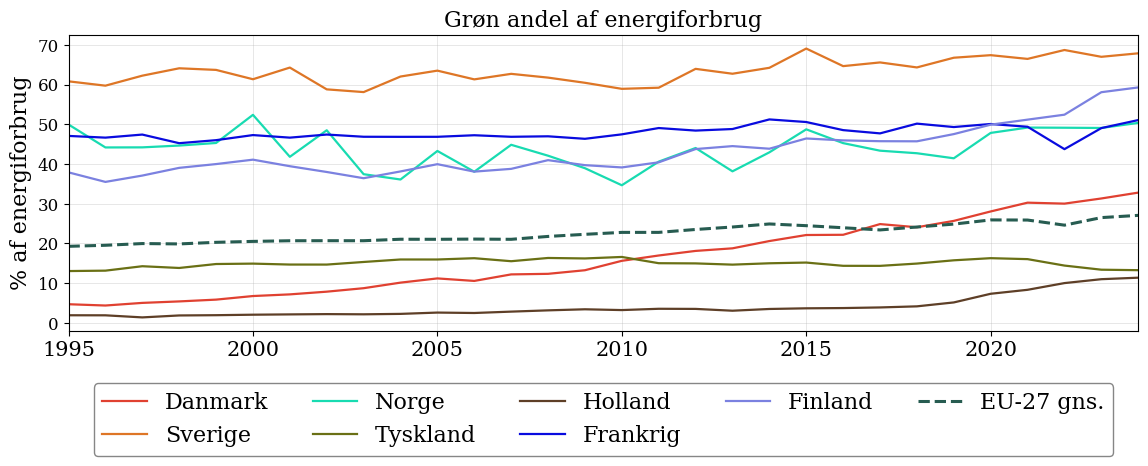

In [14]:
years = np.sort(df_share.year.unique())

fig, ax = plt.subplots(figsize=(12, 5))

for geo in countries:
    s = df_share[df_share.geo == geo].sort_values('year')
    if s.empty:
        continue
    ax.plot(s.year, s.green_pct,
            color=PALETTE[geo], ls=STYLE[geo], lw=LW[geo],
            label=var_groups.country_names[geo])

style_ax(ax, years, step=5)
ax.set_ylabel('% af energiforbrug')
ax.set_title('Grøn andel af energiforbrug')
legend(ax, ncol=5, loc='center', bbox_to_anchor=(0.5,-0.3))
plt.tight_layout()
plt.show()

### Kildernes bidrag til grøn andel (seneste år, stablede søjler)

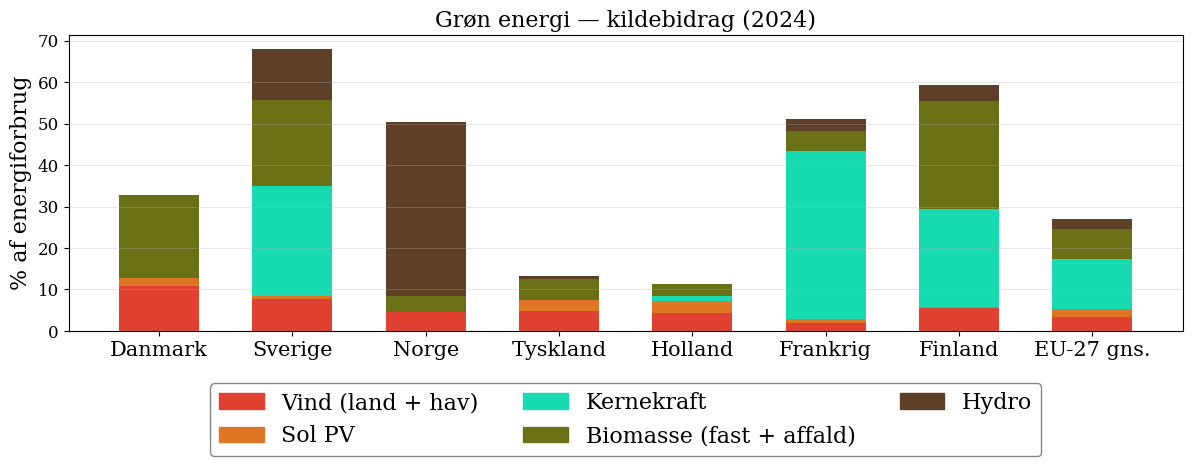

In [11]:
last_year = int(df_share.year.max())

# Per-source shares for last year
df_src = (
    df_green[df_green.year == last_year]
    .merge(df_total[df_total.year == last_year], on=['geo','year'])
    .assign(src_pct=lambda d: d['value'] / d['total_tj'] * 100)
    [['geo', 'siec', 'label', 'src_pct']]
)

# Pivot: rows = countries, columns = sources (ordered as GREEN_SOURCES)
pivot = (
    df_src.pivot(index='geo', columns='label', values='src_pct')
    .reindex(countries)
    .reindex(columns=list(GREEN_SOURCES.values()))
    .fillna(0)
)

src_colors = dict(zip(GREEN_SOURCES.values(), SEC_PALETTE[:len(GREEN_SOURCES)]))

x      = np.arange(len(pivot))
bottom = np.zeros(len(x))
patches = []

fig, ax = plt.subplots(figsize=(12, 5))

for src in GREEN_SOURCES.values():
    vals = pivot[src].to_numpy()
    ax.bar(x, vals, bottom=bottom, color=src_colors[src], width=0.6, label=src)
    bottom += vals
    patches.append(Patch(color=src_colors[src], label=src))

ax.set_xticks(x)
ax.set_xticklabels([var_groups.country_names[g] for g in pivot.index], ha='center')
ax.set_ylabel('% af energiforbrug')
ax.set_title(f'Grøn energi — kildebidrag ({last_year})')
ax.grid(axis='y', linewidth=0.6, alpha=0.35)
ax.legend(handles=patches, frameon=True, framealpha=0.95, edgecolor='0.5',
          fancybox=True, ncols=3,
          bbox_to_anchor=(0.5,-0.3), loc='center'
          )
plt.tight_layout()
plt.show()